# 分类指标

https://www.runoob.com/ml/ml-classification-metrics.html

在机器学习的世界里，构建一个分类模型只是第一步。就像一位医生不能仅凭感觉判断病情，我们也需要一套科学的体检指标来评估模型的健康状况。这些指标就是分类指标，它们能告诉我们模型预测得有多准、哪里做得好、哪里还有不足。

今天，我们将一起学习这些至关重要的评估工具。

## 为什么需要分类指标？

想象一下，你训练了一个模型来识别邮件是否为垃圾邮件。模型对 100 封邮件进行了预测，你可能会问：

- 预测对了多少封？：准确率。
- 在真正的垃圾邮件中，它找出了多少？：召回率
- 它说是垃圾邮件的，有多少真的是垃圾？：精确率

如果只用对了多少来评判，就像只用考试总分评价学生，会忽略很多重要信息。不同的业务场景关注的重点不同：
- 疾病诊断：我们更关心别漏掉任何一个病人（高召回率），哪怕多检查一些健康的人（牺牲一些精确率）。
- 垃圾邮件过滤：我们更关心别把重要邮件扔进垃圾箱（高精确率），哪怕漏掉一些垃圾邮件（牺牲一些召回率）。


## 核心概念：混淆矩阵

几乎所有分类指标都源于一个强大的工具——混淆矩阵。它是理解模型预测结果的"全景地图"。

它是一个表格，展示了模型预测结果与真实标签之间的所有四种可能情况。

In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 假设我们有真实标签和预测标签
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]  # 1代表垃圾邮件，0代表正常邮件
y_pred = [1, 0, 0, 1, 0, 0, 1, 1, 0, 1]  # 模型的预测结果

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[4 1]
 [1 4]]


![](./pic/confusion_matrix.png)

让我们拆解这四个核心术语：

| 术语 | 缩写 | 含义 | 在垃圾邮件例子中的解释 | 
| :---: | :---: | :---: | :---: | 
| 真正例 | TP | 模型预测为正，真实是也是正 | 模型正确识别出的垃圾邮件 |
| 假正例 | FP | 模型预测为正，但真是是负 | 模型误判为垃圾邮件的正常邮件 | 
| 真负例 | TN | 模型预测为负，真实也是负 | 模型正确识别出的正常邮件 | 
| 假负例 | FN | 模型预测为负，但真是是正 | 模型漏掉的垃圾邮件 |

记忆技巧：

- 真/假 指的是预测是否正确。
- 正/负 指的是模型的预测结果。

## 核心分类指标详解

有了混淆矩阵，我们就可以像用公式计算一样，得出各种评估指标。



### 准确率

准确率衡量了模型预测正确的样本占总样本的比例

$$
准确率 = \frac { TP + TN } { TP + TN + FP + FN  }
$$

In [3]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"准确率: {accuracy:.2f}")  # 输出: 0.80 (8/10)

准确率: 0.80


- 优点：非常直观，易于理解。
- 缺点：在数据不平衡时具有误导性。例如，如果 99% 的邮件都是正常邮件，一个把所有邮件都预测为正常的"笨模型"，准确率也能高达 99%，但它一个垃圾邮件都抓不到。

### 精确率

精确率关注模型预测出的正例中有多少是真正的正例，衡量预测结果的可靠性：
$$
精确率 = \frac {TP} {TP + FP}
$$

In [4]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred)
print(f"精确率: {precision:.2f}")  # 输出: 0.80 (TP=4, TP+FP=5)

精确率: 0.80


### 召回率

召回率关注所有真实的正例中被模型找出了多少。衡量模型发现正例的能力。

$$
召回率 = \frac{ TP }{ TP + FN }
$$

在所有真正的垃圾邮件中，我们找出了多少？ 高召回率意味着：模型很少漏掉真正的垃圾邮件。

In [5]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred)
print(f"召回率: {recall:.2f}")  # 输出: 0.80 (TP=4, TP+FN=5)

召回率: 0.80


### F1 分数 - 精确率与召回率的调和平均

精确率和召回率通常相互矛盾（提高一个，另一个往往会降低）。F1 分数是它们的调和平均数，旨在找到一个平衡点。

$$
F1 = 2 \times \frac { 精确率  \times 召回率 }{精确率 + 召回率 }
$$

调和平均的特点：它更倾向于惩罚极端值。只有当精确率和召回率都较高时，F1 分数才会高。

In [6]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print(f"F1分数: {f1:.2f}")  # 输出: 0.80

F1分数: 0.80


![](./pic/confusion_matrix_select.png)

## 

## 进阶指标：ROC 曲线与 AUC

当模型的预测结果是一个概率值（例如，某邮件是垃圾邮件的概率为 0.8）时，我们需要设定一个阈值（如 0.5）来决定最终分类。ROC 曲线帮助我们评估模型在不同阈值下的整体性能。

### 真正率与假正率

- 真正率：就是召回率：$TPR = TP / (TP + FN)$
- 假正率：所有真实负例中，被错误预判为正例的比例：$FPR =  FP / (FP + TN)$

### ROC 曲线

ROC 曲线以 FPR 为横轴，TPR 为纵轴。曲线上的每一个点，都对应一个特定的分类阈值。

- 理想点：左上角 (0, 1)，即 FPR=0（没有误报），TPR=1（全部召回）。
- 随机线：从 (0,0) 到 (1,1) 的对角线，代表一个随机猜测模型的性能。

### AUC 值

AUC 是 ROC 曲线下的面积。

- AUC = 1：完美模型。
- AUC = 0.5：模型没有区分能力，等同于随机猜测。
- 0.5 < AUC < 1：模型具有一定的预测能力，值越大越好。
- AUC < 0.5：模型比随机猜测还差，通常意味着预测方向反了。

AUC 的优势在于它对类别不平衡不敏感，并且评估的是模型整体的排序能力（将正样本排在负样本前面的能力）。

AUC 值: 1.00


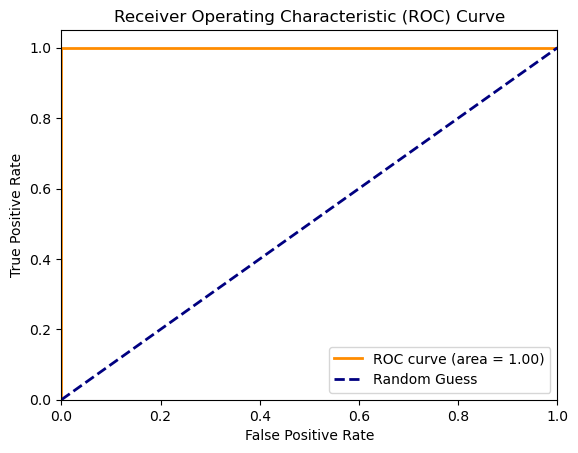

In [7]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true = [1, 0, 1, 0, 1]
# 模型预测为正例的概率
y_scores = [0.9, 0.4, 0.6, 0.3, 0.8] 

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"AUC 值: {roc_auc:.2f}")

# 绘制ROC曲线（可选，需要matplotlib）
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### 多分类问题的指标

当类别超过两个时（如识别猫、狗、兔子），上述指标可以通过以下方式扩展：

- 宏平均：先计算每个类别的指标（如精确率），再对所有类别的指标取算术平均。平等看待每个类别。
- 微平均：先汇总所有类别的 TP、FP 等，再用汇总后的值计算一个全局指标。平等看待每个样本，受大类别影响更大。

在 Scikit-learn 中，可以通过 average 参数指定：

In [ ]:
from sklearn.metrics import precision_score
# y_true 和 y_pred 现在是多类标签，例如 [0, 1, 2, 0, 1]

precision_macro = precision_score(y_true, y_pred, average='macro') # 宏平均
precision_micro = precision_score(y_true, y_pred, average='micro') # 微平均

## 实践练习

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test) # 获取预测概率，用于AUC

In [14]:
print("=== 混淆矩阵 ===")
print(confusion_matrix(y_test, y_test))

=== 混淆矩阵 ===
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [15]:
print("\n=== 分类报告（包含精确率、召回率、F1）===")
print(classification_report(y_test, y_pred, target_names=target_names))


=== 分类报告（包含精确率、召回率、F1）===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [16]:
print(f"\n=== 准确率 ===")
print(f"{accuracy_score(y_test, y_pred):.4f}")


=== 准确率 ===
1.0000


In [17]:
from sklearn.metrics import roc_auc_score
# 注意：roc_auc_score 在多分类时需要指定 multi_class='ovr' (One-vs-Rest) 和 average
try:
    auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    print(f"\n=== 宏平均 AUC (OvR) ===")
    print(f"{auc_ovr:.4f}")
except Exception as e:
    print(f"\n计算AUC时出错（可能某些类别在测试集中未出现）: {e}")


=== 宏平均 AUC (OvR) ===
1.0000
